In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Montbrio-Pazo-Roxin Model

The **Montbrio-Pazo-Roxin (MPR) model** is an *exact* mean-field reduction of an all-to-all network of quadratic integrate-and-fire (QIF) neurons, derived via the Ott-Antonsen ansatz. The two macroscopic variables are the population firing rate $r$ and the mean membrane potential $v$:

$$\tau\dot r = \tfrac{\Delta}{\pi\tau} + 2 r v,\qquad \tau\dot v = v^2 + \eta + J\tau r - (\pi\tau r)^2.$$

Unlike heuristic rate models, MPR exactly tracks the spiking network and supports next-generation neural-mass whole-brain modeling.

**Reference:** Montbrio, Pazo & Roxin (2015), *Macroscopic description for networks of spiking neurons*, Physical Review X 5:021028.

## Build the model

In [2]:
node = brainmass.MontbrioPazoRoxinStep(in_size=1, eta=-5.0, J=15.0)
node

MontbrioPazoRoxinStep(
  in_size=(1,),
  out_size=(1,),
  tau=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(1., "ms")
  ),
  eta=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(-5., dtype=float32)
  ),
  delta=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(1., "Hz")
  ),
  J=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(15., dtype=float32)
  ),
  init_r=Uniform(low=0 Hz, high=0.05 Hz),
  init_v=Uniform(low=0, high=0.05),
  method=exp_euler
)

## Run a simulation

With a transient depolarizing drive `v_inp` the population emits a burst that the firing rate `r` tracks exactly.

In [3]:
sim = brainmass.Simulator(node, dt=0.01 * u.ms)
res = sim.run(40. * u.ms, inputs=lambda i, t: (None, 3.0),
              monitors=['r', 'v'])
res['r'].shape, u.get_unit(res['r'])

((4000, 1), Unit("Hz"))

## Visualize

The firing rate is unit-aware (`Hz`); `viz` strips units automatically. The phase portrait shows the $(r, v)$ trajectory.

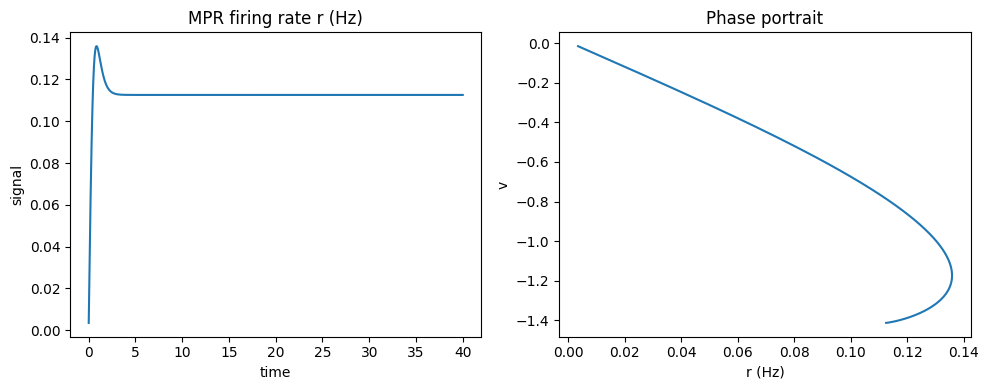

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
brainmass.viz.plot_timeseries(res['r'], ts=res['ts'], ax=axes[0])
axes[0].set_title('MPR firing rate r (Hz)')
brainmass.viz.plot_phase_portrait(res['r'], res['v'], ax=axes[1])
axes[1].set_xlabel('r (Hz)'); axes[1].set_ylabel('v')
axes[1].set_title('Phase portrait')
plt.tight_layout()
plt.show()

## Try it: vary the excitability `eta`

The mean external current `eta` moves the population between a low-rate resting state and a high-rate active state.

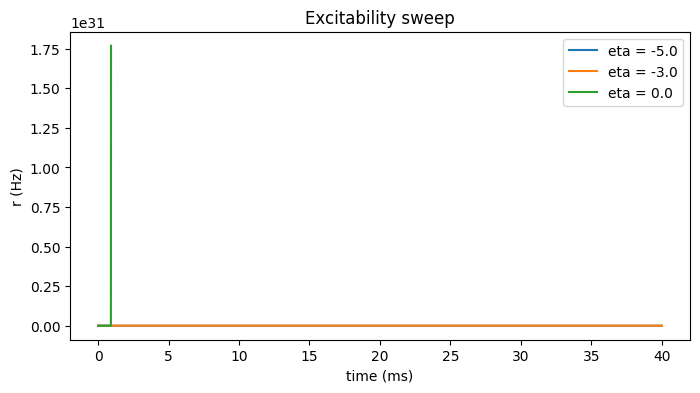

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for eta in [-5.0, -3.0, 0.0]:
    m = brainmass.MontbrioPazoRoxinStep(in_size=1, eta=eta, J=15.0)
    r = brainmass.Simulator(m, dt=0.01 * u.ms).run(
        40. * u.ms, inputs=lambda i, t: (None, 3.0), monitors=['r'])
    ax.plot(u.get_magnitude(r['ts']), u.get_magnitude(r['r'])[:, 0], label=f'eta = {eta}')
ax.set_xlabel('time (ms)'); ax.set_ylabel('r (Hz)'); ax.legend()
ax.set_title('Excitability sweep')
plt.show()